# Scientific LLM Fine-Tuning: Dataset Creation

This notebook prepares and validates the instruction-tuning dataset used for:

- LoRA supervised fine-tuning
- Model evaluation
- Optional GRPO training

The notebook loads the source datasets, checks data quality, removes duplicates, creates reproducible splits, and saves the final dataset.

**Author:** Milad Saeedi

## Read the data

In [34]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# Project directories
DATA_DIR = Path("../data")
OUTPUT_DIR = DATA_DIR / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Source dataset files
SOURCE_FILES = [
    "Answered_questions.json",
    "Concept_Explanation_examples_200.json",
    "Abstract_summaries_200.json",
    "Method_comparisons_200.json",
    "Technical_simplifications_200.json",
    "Bullet_generation_200.json",
    "Data_analysis_200.json",
    "Code_generation_100.json",
]


print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("Number of source files:", len(SOURCE_FILES))


Data directory: /Users/miladsaeedi/Desktop/Daily_Work_load/LLM_Hug_face/LLM_Course_projects/Project2/data
Output directory: /Users/miladsaeedi/Desktop/Daily_Work_load/LLM_Hug_face/LLM_Course_projects/Project2/data/processed
Number of source files: 8


## 2. Load Source Datasets

Load all JSON files, combine them into one table, and record where each example came from.

In [35]:
def load_source_files(data_dir, source_files):
    all_records = []

    for filename in source_files:
        file_path = data_dir / filename

        # Check that the file exists
        if not file_path.exists():
            raise FileNotFoundError(
                f"File not found: {file_path}\n"
                "Make sure the file is inside the data folder."
            )

        # Load JSON
        with open(file_path, "r", encoding="utf-8") as file:
            records = json.load(file)

        # Confirm the JSON contains a list of examples
        if not isinstance(records, list):
            raise TypeError(
                f"{filename} must contain a list of examples."
            )

        print(f"{filename}: {len(records)} examples")

        # Add source information to every example
        for row_number, record in enumerate(records):
            if not isinstance(record, dict):
                raise TypeError(
                    f"{filename}, row {row_number}: "
                    "each example must be a dictionary."
                )

            record = record.copy()
            record["source_file"] = filename
            record["source_row"] = row_number

            all_records.append(record)

    return pd.DataFrame(all_records)

In [36]:
raw_df = load_source_files(
    data_dir=DATA_DIR,
    source_files=SOURCE_FILES,
)

print("\nTotal examples:", len(raw_df))

raw_df.head()

Answered_questions.json: 256 examples
Concept_Explanation_examples_200.json: 200 examples
Abstract_summaries_200.json: 220 examples
Method_comparisons_200.json: 200 examples
Technical_simplifications_200.json: 200 examples
Bullet_generation_200.json: 200 examples
Data_analysis_200.json: 200 examples
Code_generation_100.json: 100 examples

Total examples: 1576


,id,category,task,difficulty,messages,source_file,source_row,source,keywords,paper_title,year,arxiv_id,doi,source_url,source_repository,source_status_note,abstract_text_type
0,201,Air Pollution,scientific_question_answering,intermediate,"[{'role': 'system', 'content': 'You are Resear...",Answered_questions.json,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202,Air Pollution,scientific_question_answering,intermediate,"[{'role': 'system', 'content': 'You are Resear...",Answered_questions.json,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,203,Air Pollution,scientific_question_answering,intermediate,"[{'role': 'system', 'content': 'You are Resear...",Answered_questions.json,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,204,Air Pollution,scientific_question_answering,intermediate,"[{'role': 'system', 'content': 'You are Resear...",Answered_questions.json,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,205,Air Pollution,scientific_question_answering,intermediate,"[{'role': 'system', 'content': 'You are Resear...",Answered_questions.json,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
raw_df.columns.tolist()

['id',
 'category',
 'task',
 'difficulty',
 'messages',
 'source_file',
 'source_row',
 'source',
 'keywords',
 'paper_title',
 'year',
 'arxiv_id',
 'doi',
 'source_url',
 'source_repository',
 'source_status_note',
 'abstract_text_type']

## 3. Validate Dataset Structure

Check that every example contains the columns required for instruction fine-tuning and inspect missing values in optional metadata fields.

In [38]:
# Columns required for every training example
REQUIRED_COLUMNS = {
    "id",
    "category",
    "task",
    "difficulty",
    "messages",
    "source_file",
    "source_row",
}

# Check whether any required columns are missing
missing_required_columns = REQUIRED_COLUMNS - set(raw_df.columns)

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_required_columns)}"
    )

print("All required columns are present.")

All required columns are present.


In [39]:
print("Dataset shape:", raw_df.shape)

raw_df.info()

Dataset shape: (1576, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1576 non-null   int64  
 1   category            1576 non-null   object 
 2   task                1576 non-null   object 
 3   difficulty          1576 non-null   object 
 4   messages            1576 non-null   object 
 5   source_file         1576 non-null   object 
 6   source_row          1576 non-null   int64  
 7   source              200 non-null    object 
 8   keywords            200 non-null    object 
 9   paper_title         220 non-null    object 
 10  year                220 non-null    float64
 11  arxiv_id            220 non-null    object 
 12  doi                 220 non-null    object 
 13  source_url          220 non-null    object 
 14  source_repository   220 non-null    object 
 15  source_status_note  220 non-n

In [40]:
missing_summary = (
    raw_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(raw_df) * 100
).round(2)

missing_summary

,missing_count,missing_percentage
keywords,1376,87.31
source,1376,87.31
paper_title,1356,86.04
source_status_note,1356,86.04
source_repository,1356,86.04
source_url,1356,86.04
doi,1356,86.04
arxiv_id,1356,86.04
year,1356,86.04
abstract_text_type,1356,86.04


In [41]:
required_missing = raw_df[list(REQUIRED_COLUMNS)].isna().sum()

required_missing

messages       0
source_row     0
difficulty     0
id             0
source_file    0
category       0
task           0
dtype: int64

In [42]:
if required_missing.sum() > 0:
    raise ValueError(
        "Missing values were found in required columns:\n"
        f"{required_missing[required_missing > 0]}"
    )

print("No missing values found in required columns.")

No missing values found in required columns.


In [43]:
TEXT_COLUMNS = [
    "category",
    "task",
    "difficulty",
]

empty_string_counts = {}

for column in TEXT_COLUMNS:
    empty_string_counts[column] = (
        raw_df[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

empty_string_counts

{'category': np.int64(0), 'task': np.int64(0), 'difficulty': np.int64(0)}

In [44]:
if any(count > 0 for count in empty_string_counts.values()):
    raise ValueError(
        f"Empty strings found in required metadata: {empty_string_counts}"
    )

print("No empty values found in category, task, or difficulty.")

No empty values found in category, task, or difficulty.


In [45]:
optional_columns = [
    column
    for column in raw_df.columns
    if column not in REQUIRED_COLUMNS
]

metadata_by_source = (
    raw_df.groupby("source_file")[optional_columns]
    .count()
)

metadata_by_source

,source,keywords,paper_title,year,arxiv_id,doi,source_url,source_repository,source_status_note,abstract_text_type
source_file,,,,,,,,,,
Abstract_summaries_200.json,0,0,220,220,220,220,220,220,220,220
Answered_questions.json,0,0,0,0,0,0,0,0,0,0
Bullet_generation_200.json,0,0,0,0,0,0,0,0,0,0
Code_generation_100.json,0,0,0,0,0,0,0,0,0,0
Concept_Explanation_examples_200.json,200,200,0,0,0,0,0,0,0,0
Data_analysis_200.json,0,0,0,0,0,0,0,0,0,0
Method_comparisons_200.json,0,0,0,0,0,0,0,0,0,0
Technical_simplifications_200.json,0,0,0,0,0,0,0,0,0,0


## 4. Validate Chat Message Format

Check that every example contains a valid system, user, and assistant message in the correct order.

In [46]:
EXPECTED_ROLES = ["system", "user", "assistant"]


def validate_messages(messages):
    """
    Validate the structure of one conversation.

    Returns
    -------
    tuple
        (is_valid, error_message)
    """

    if not isinstance(messages, list):
        return False, "messages is not a list"

    if len(messages) != 3:
        return False, f"expected 3 messages, found {len(messages)}"

    roles = []

    for index, message in enumerate(messages):
        if not isinstance(message, dict):
            return False, f"message {index} is not a dictionary"

        if "role" not in message:
            return False, f"message {index} is missing 'role'"

        if "content" not in message:
            return False, f"message {index} is missing 'content'"

        role = message["role"]
        content = message["content"]

        if not isinstance(role, str):
            return False, f"message {index} role is not a string"

        if not isinstance(content, str):
            return False, f"message {index} content is not a string"

        if not content.strip():
            return False, f"message {index} content is empty"

        roles.append(role)

    if roles != EXPECTED_ROLES:
        return False, (
            f"expected roles {EXPECTED_ROLES}, "
            f"found {roles}"
        )

    return True, ""

In [47]:
message_validation = raw_df["messages"].apply(validate_messages)

raw_df["message_schema_valid"] = message_validation.str[0]
raw_df["message_schema_error"] = message_validation.str[1]

In [48]:
raw_df["message_schema_valid"].value_counts()

message_schema_valid
True    1576
Name: count, dtype: int64

In [49]:
invalid_message_rows = raw_df.loc[
    ~raw_df["message_schema_valid"],
    [
        "source_file",
        "source_row",
        "id",
        "message_schema_error",
        "messages",
    ],
]

print("Invalid examples:", len(invalid_message_rows))

invalid_message_rows.head(20)

Invalid examples: 0


,source_file,source_row,id,message_schema_error,messages


In [50]:
if not invalid_message_rows.empty:
    raise ValueError(
        f"{len(invalid_message_rows)} examples have invalid message structures. "
        "Review invalid_message_rows before continuing."
    )

print("All examples have valid system-user-assistant messages.")

All examples have valid system-user-assistant messages.


In [51]:
sample_messages = raw_df.loc[0, "messages"]

for message in sample_messages:
    print(f"{message['role'].upper()}:")
    print(message["content"])
    print("-" * 80)

SYSTEM:
You are ResearchGPT, a scientific research assistant.
--------------------------------------------------------------------------------
USER:
Why must spatial autocorrelation be considered in air pollution studies?
--------------------------------------------------------------------------------
ASSISTANT:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.
--------------------------------------------------------------------------------


## 5. Extract Conversation Text

Extract the system prompt, user instruction, and assistant response into separate columns for easier analysis and duplicate detection.

In [52]:
# Create a working copy so the original loaded data remains unchanged
df = raw_df.copy()


def get_message_content(messages, role):
    """
    Extract the text belonging to a specific message role.
    """
    for message in messages:
        if message["role"] == role:
            return message["content"].strip()

    return None

In [53]:
df["system_prompt"] = df["messages"].apply(
    lambda messages: get_message_content(messages, "system")
)

df["instruction"] = df["messages"].apply(
    lambda messages: get_message_content(messages, "user")
)

df["response"] = df["messages"].apply(
    lambda messages: get_message_content(messages, "assistant")
)

In [54]:
df[["id", "task", "system_prompt", "instruction","response"]].head()

,id,task,system_prompt,instruction,response
0,201,scientific_question_answering,"You are ResearchGPT, a scientific research ass...",Why must spatial autocorrelation be considered...,Air pollution measurements collected near one ...
1,202,scientific_question_answering,"You are ResearchGPT, a scientific research ass...",Why can random cross-validation overestimate a...,"Random splitting can place nearby, highly corr..."
2,203,scientific_question_answering,"You are ResearchGPT, a scientific research ass...",What causes NO₂ hotspots?,NO₂ hotspots commonly form near congested road...
3,204,scientific_question_answering,"You are ResearchGPT, a scientific research ass...",What is the difference between PM2.5 and UFP?,PM2.5 refers to fine particulate matter under ...
4,205,scientific_question_answering,"You are ResearchGPT, a scientific research ass...",Why are highways pollution hotspots?,Highways concentrate large volumes of continuo...


In [55]:
extracted_columns = [
    "system_prompt",
    "instruction",
    "response",
]

df[extracted_columns].isna().sum()

system_prompt    0
instruction      0
response         0
dtype: int64

In [56]:
empty_extracted_text = {
    column: df[column].str.strip().eq("").sum()
    for column in extracted_columns
}

empty_extracted_text

{'system_prompt': np.int64(0),
 'instruction': np.int64(0),
 'response': np.int64(0)}

In [57]:
if any(count > 0 for count in empty_extracted_text.values()):
    raise ValueError(
        f"Empty extracted text found: {empty_extracted_text}"
    )

print("System prompts, instructions, and responses were extracted successfully.")

System prompts, instructions, and responses were extracted successfully.


In [58]:
for index in range(3):
    print(f"EXAMPLE {index + 1}")
    print("Task:", df.loc[index, "task"])
    print("\nSYSTEM:")
    print(df.loc[index, "system_prompt"])

    print("\nUSER:")
    print(df.loc[index, "instruction"])

    print("\nASSISTANT:")
    print(df.loc[index, "response"])

    print("\n" + "=" * 100 + "\n")

EXAMPLE 1
Task: scientific_question_answering

SYSTEM:
You are ResearchGPT, a scientific research assistant.

USER:
Why must spatial autocorrelation be considered in air pollution studies?

ASSISTANT:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.


EXAMPLE 2
Task: scientific_question_answering

SYSTEM:
You are ResearchGPT, a scientific research assistant.

USER:
Why can random cross-validation overestimate air pollution model performance?

ASSISTANT:
Random splitting can place nearby, highly correlated pollution observations in both training and test sets. The model then benefits from spatial leakage and appears more accurate than it is at genuinely unmonitored locations.


EXAMPLE 3
Task: scientific_question_answering

SYSTEM:
You are ResearchGPT, a scientific research assistant.


## 6. Detect Duplicate IDs and Duplicate Conversations

Check repeated source IDs separately from repeated conversation content. Duplicate IDs can be replaced later, while duplicate conversations may need to be removed.

6.1 Check duplicate IDs

In [59]:
duplicate_id_mask = df["id"].duplicated(keep=False)

duplicate_id_rows = df.loc[
    duplicate_id_mask,
    [
        "id",
        "source_file",
        "source_row",
        "task",
        "instruction",
    ],
].sort_values(["id", "source_file", "source_row"])

print("Rows with repeated IDs:", len(duplicate_id_rows))
print("Number of repeated ID values:", df.loc[duplicate_id_mask, "id"].nunique())

duplicate_id_rows.head(20)

Rows with repeated IDs: 312
Number of repeated ID values: 156


,id,source_file,source_row,task,instruction
466,401,Abstract_summaries_200.json,10,summarization,Summarize the following faithfully paraphrased...
200,401,Answered_questions.json,200,scientific_question_answering,What is epoch?
467,402,Abstract_summaries_200.json,11,summarization,Summarize the following faithfully paraphrased...
201,402,Answered_questions.json,201,scientific_question_answering,What is loss function?
468,403,Abstract_summaries_200.json,12,summarization,Summarize the following faithfully paraphrased...
202,403,Answered_questions.json,202,scientific_question_answering,What is accuracy?
469,404,Abstract_summaries_200.json,13,summarization,Summarize the following faithfully paraphrased...
203,404,Answered_questions.json,203,scientific_question_answering,What is precision?
470,405,Abstract_summaries_200.json,14,summarization,Summarize the following faithfully paraphrased...
204,405,Answered_questions.json,204,scientific_question_answering,What is recall?


In [60]:
 duplicate_id_counts = (
    df.loc[duplicate_id_mask, "id"]
    .value_counts()
    .to_frame("count")
)

duplicate_id_counts.head(20)

,count
id,
401,2
902,2
795,2
796,2
797,2
798,2
799,2
800,2
901,2


6.2 Normalize text before checking duplicates

In [61]:
import re
def normalize_text(text):
    """
    Normalize text for duplicate detection.

    This ignores:
    - capitalization,
    - leading and trailing spaces,
    - repeated whitespace.
    """
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)

    return text
df["normalized_system"] = df["system_prompt"].apply(normalize_text)
df["normalized_instruction"] = df["instruction"].apply(normalize_text)
df["normalized_response"] = df["response"].apply(normalize_text)

6.3 Detect fully duplicated conversations

In [62]:
CONVERSATION_COLUMNS = [
    "normalized_system",
    "normalized_instruction",
    "normalized_response",
]

duplicate_conversation_mask = df.duplicated(
    subset=CONVERSATION_COLUMNS,
    keep=False,
)

duplicate_conversations = df.loc[
    duplicate_conversation_mask,
    [
        "id",
        "source_file",
        "source_row",
        "task",
        "instruction",
        "response",
    ],
].sort_values(
    ["instruction", "response", "source_file"]
)

print(
    "Rows belonging to duplicate conversation groups:",
    len(duplicate_conversations),
)

print(
    "Extra rows that would be removed:",
    df.duplicated(
        subset=CONVERSATION_COLUMNS,
        keep="first",
    ).sum(),
)

duplicate_conversations.head(20)

Rows belonging to duplicate conversation groups: 0
Extra rows that would be removed: 0


,id,source_file,source_row,task,instruction,response


6.4 Check repeated instructions separately

In [64]:
duplicate_instruction_mask = df.duplicated(
    subset=[
        "normalized_system",
        "normalized_instruction",
    ],
    keep=False,
)

repeated_instructions = df.loc[
    duplicate_instruction_mask,
    [
        "id",
        "source_file",
        "source_row",
        "task",
        "normalized_instruction",
        "instruction",
        "response",
    ],
].sort_values(
    ["normalized_instruction", "source_file", "source_row"]
)

print("Rows with repeated instructions:", len(repeated_instructions))

repeated_instructions.head(30)

Rows with repeated instructions: 0


,id,source_file,source_row,task,normalized_instruction,instruction,response


In [65]:
instruction_response_counts = (
    df.groupby(
        [
            "normalized_system",
            "normalized_instruction",
        ]
    )["normalized_response"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("unique_responses")
)

instruction_response_counts.head(20)

unique_responses
normalized_system                                  normalized_instruction                                              
you are researchgpt, a scientific data analyst.    interpret the following calibration result: amo...                 1
you are researchgpt, a scientific research assi... summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1
                                                   summarize the following faithfully paraphrased ...                 1

## 7. Remove Full Duplicate Conversations

Remove only exact normalized conversation duplicates. Repeated prompts with different responses are retained.

In [66]:
df = df.rename(columns={"id": "source_id"})

In [67]:
duplicate_rows_to_remove = df.duplicated(
    subset=[
        "normalized_system",
        "normalized_instruction",
        "normalized_response",
    ],
    keep="first",
)

print("Rows before duplicate removal:", len(df))
print("Rows to remove:", duplicate_rows_to_remove.sum())

Rows before duplicate removal: 1576
Rows to remove: 0


In [68]:
rows_before = len(df)

df = (
    df.loc[~duplicate_rows_to_remove]
    .copy()
    .reset_index(drop=True)
)

rows_removed = rows_before - len(df)

print("Rows removed:", rows_removed)
print("Rows remaining:", len(df))

Rows removed: 0
Rows remaining: 1576


In [69]:
df.insert(
    0,
    "id",
    [
        f"researchgpt-{index:05d}"
        for index in range(1, len(df) + 1)
    ],
)

In [70]:
print("New IDs are unique:", df["id"].is_unique)
print("Original IDs retained:", "source_id" in df.columns)
print("Final number of examples:", len(df))

New IDs are unique: True
Original IDs retained: True
Final number of examples: 1576


In [71]:
remaining_duplicates = df.duplicated(
    subset=[
        "normalized_system",
        "normalized_instruction",
        "normalized_response",
    ]
).sum()

print("Remaining full duplicate conversations:", remaining_duplicates)

Remaining full duplicate conversations: 0


In [72]:
df[
    [
        "id",
        "source_id",
        "source_file",
        "source_row",
        "task",
    ]
].head(10)

,id,source_id,source_file,source_row,task
0,researchgpt-00001,201,Answered_questions.json,0,scientific_question_answering
1,researchgpt-00002,202,Answered_questions.json,1,scientific_question_answering
2,researchgpt-00003,203,Answered_questions.json,2,scientific_question_answering
3,researchgpt-00004,204,Answered_questions.json,3,scientific_question_answering
4,researchgpt-00005,205,Answered_questions.json,4,scientific_question_answering
5,researchgpt-00006,206,Answered_questions.json,5,scientific_question_answering
6,researchgpt-00007,207,Answered_questions.json,6,scientific_question_answering
7,researchgpt-00008,208,Answered_questions.json,7,scientific_question_answering
8,researchgpt-00009,209,Answered_questions.json,8,scientific_question_answering
9,researchgpt-00010,210,Answered_questions.json,9,scientific_question_answering


## 8. Analyze Dataset Quality

Inspect the distribution of tasks and difficulty levels and summarize instruction and response lengths before creating dataset splits.

8.1 Task distribution

In [73]:
task_distribution = (
    df["task"]
    .value_counts()
    .rename_axis("task")
    .to_frame("count")
)

task_distribution["percentage"] = (
    task_distribution["count"] / len(df) * 100
).round(2)

task_distribution

,count,percentage
task,,
scientific_question_answering,256,16.24
summarization,220,13.96
concept_explanation,200,12.69
method_comparison,200,12.69
technical_simplification,200,12.69
bullet_generation,200,12.69
data_analysis,200,12.69
code_generation,100,6.35


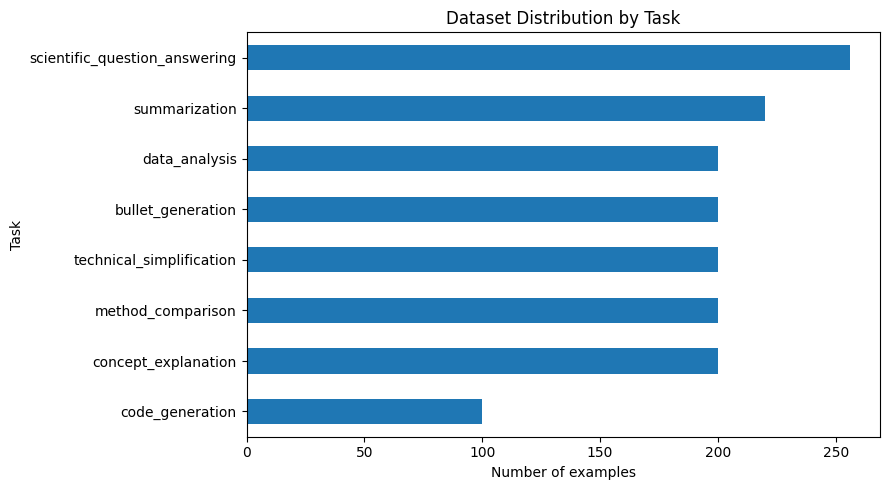

In [74]:
import matplotlib.pyplot as plt


task_distribution["count"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
)

plt.xlabel("Number of examples")
plt.ylabel("Task")
plt.title("Dataset Distribution by Task")
plt.tight_layout()
plt.show()

8.2 Difficulty distribution

In [75]:
difficulty_distribution = (
    df["difficulty"]
    .value_counts()
    .rename_axis("difficulty")
    .to_frame("count")
)

difficulty_distribution["percentage"] = (
    difficulty_distribution["count"] / len(df) * 100
).round(2)

difficulty_distribution

,count,percentage
difficulty,,
intermediate,1184,75.13
easy,201,12.75
advanced,128,8.12
beginner,63,4.00


In [76]:
task_difficulty_table = pd.crosstab(
    df["task"],
    df["difficulty"],
)

task_difficulty_table

difficulty,advanced,beginner,easy,intermediate
task,,,,
bullet_generation,80,0,52,68
code_generation,2,0,49,49
concept_explanation,46,63,0,91
data_analysis,0,0,0,200
method_comparison,0,0,0,200
scientific_question_answering,0,0,0,256
summarization,0,0,0,220
technical_simplification,0,0,100,100


In [77]:
task_difficulty_percentage = pd.crosstab(
    df["task"],
    df["difficulty"],
    normalize="index",
).mul(100).round(2)

task_difficulty_percentage

difficulty,advanced,beginner,easy,intermediate
task,,,,
bullet_generation,40.0,0.0,26.0,34.0
code_generation,2.0,0.0,49.0,49.0
concept_explanation,23.0,31.5,0.0,45.5
data_analysis,0.0,0.0,0.0,100.0
method_comparison,0.0,0.0,0.0,100.0
scientific_question_answering,0.0,0.0,0.0,100.0
summarization,0.0,0.0,0.0,100.0
technical_simplification,0.0,0.0,50.0,50.0


8.3 Calculate character and word lengths

In [78]:
df["instruction_characters"] = df["instruction"].str.len()
df["response_characters"] = df["response"].str.len()

df["instruction_words"] = (
    df["instruction"]
    .str.split()
    .str.len()
)

df["response_words"] = (
    df["response"]
    .str.split()
    .str.len()
)

In [79]:
length_columns = [
    "instruction_characters",
    "response_characters",
    "instruction_words",
    "response_words",
]

df[length_columns].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,instruction_characters,response_characters,instruction_words,response_words
count,1576.00,1576.00,1576.00,1576.00
mean,116.34,297.29,15.18,39.33
std,106.48,217.09,13.16,28.02
min,13.00,52.00,2.00,9.00
50%,64.00,226.00,9.00,31.00
75%,197.00,348.00,24.00,44.00
90%,318.00,761.50,39.00,98.00
95%,343.25,809.00,43.00,108.00
99%,368.25,869.50,47.00,117.00
max,439.00,1250.00,55.00,183.00


8.4 Inspect unusually short examples

In [80]:
short_instructions = df.loc[
    df["instruction_words"] < 4,
    [
        "id",
        "task",
        "instruction",
        "response",
        "source_file",
        "source_row",
    ],
]

print("Instructions shorter than 4 words:", len(short_instructions))

short_instructions.head(20)

Instructions shorter than 4 words: 179


,id,task,instruction,response,source_file,source_row
62,researchgpt-00063,scientific_question_answering,What is kriging?,Kriging is an advanced geostatistical interpol...,Answered_questions.json,62
80,researchgpt-00081,scientific_question_answering,What is GeoPandas?,GeoPandas is an open-source Python library tha...,Answered_questions.json,80
81,researchgpt-00082,scientific_question_answering,What is Rasterio?,"Rasterio is a Python library for reading, writ...",Answered_questions.json,81
101,researchgpt-00102,scientific_question_answering,What is methane?,Methane is a potent greenhouse gas emitted dur...,Answered_questions.json,101
102,researchgpt-00103,scientific_question_answering,What is ozone?,Ozone is a molecule composed of three oxygen a...,Answered_questions.json,102
104,researchgpt-00105,scientific_question_answering,What is biodiversity?,Biodiversity encompasses the immense variety o...,Answered_questions.json,104
128,researchgpt-00129,scientific_question_answering,What is deforestation?,Deforestation is the permanent removal of tree...,Answered_questions.json,128
129,researchgpt-00130,scientific_question_answering,What is desertification?,Desertification is a type of land degradation ...,Answered_questions.json,129
137,researchgpt-00138,scientific_question_answering,What is PM2.5?,PM2.5 consists of airborne particles with aero...,Answered_questions.json,137
138,researchgpt-00139,scientific_question_answering,What is PM10?,PM10 includes airborne particles with aerodyna...,Answered_questions.json,138


In [82]:
short_responses = df.loc[
    df["response_words"] < 10,
    [
        "id",
        "task",
        "instruction",
        "response",
        "source_file",
        "source_row",
    ],
]

print("Responses shorter than 10 words:", len(short_responses))

short_responses.head(20)

Responses shorter than 10 words: 12


,id,task,instruction,response,source_file,source_row
460,researchgpt-00461,summarization,Summarize the following faithfully paraphrased...,Responsible-AI issues are still inconsistently...,Abstract_summaries_200.json,4
487,researchgpt-00488,summarization,Summarize the following faithfully paraphrased...,Foundation-model embeddings enable content-bas...,Abstract_summaries_200.json,31
493,researchgpt-00494,summarization,Summarize the following faithfully paraphrased...,Multiscale temporal fusion improves forecasts ...,Abstract_summaries_200.json,37
499,researchgpt-00500,summarization,Summarize the following faithfully paraphrased...,Sequence-based calibration captures temporal e...,Abstract_summaries_200.json,43
533,researchgpt-00534,summarization,Summarize the following faithfully paraphrased...,Region-aware adaptation improves transfer of c...,Abstract_summaries_200.json,77
577,researchgpt-00578,summarization,Summarize the following faithfully paraphrased...,Self-supervised satellite pretraining strength...,Abstract_summaries_200.json,121
582,researchgpt-00583,summarization,Summarize the following faithfully paraphrased...,Efficient multimodal pretraining makes hypersp...,Abstract_summaries_200.json,126
619,researchgpt-00620,summarization,Summarize the following faithfully paraphrased...,Multi-scale spatial and temporal modeling impr...,Abstract_summaries_200.json,163
622,researchgpt-00623,summarization,Summarize the following faithfully paraphrased...,Cross-sensor benchmarking exposes important di...,Abstract_summaries_200.json,166
657,researchgpt-00658,summarization,Summarize the following faithfully paraphrased...,Hex2vec turns map-tagged hexagons into reusabl...,Abstract_summaries_200.json,201


 8.5 Inspect unusually long examples

In [83]:
long_instructions = df.nlargest(
    10,
    "instruction_words",
)[
    [
        "id",
        "task",
        "instruction_words",
        "instruction",
        "source_file",
    ]
]

long_instructions

,id,task,instruction_words,instruction,source_file
463,researchgpt-00464,summarization,55,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
459,researchgpt-00460,summarization,54,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
467,researchgpt-00468,summarization,54,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
457,researchgpt-00458,summarization,50,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
491,researchgpt-00492,summarization,49,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
468,researchgpt-00469,summarization,48,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
533,researchgpt-00534,summarization,48,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
536,researchgpt-00537,summarization,48,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
581,researchgpt-00582,summarization,48,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json
586,researchgpt-00587,summarization,48,Summarize the following faithfully paraphrased...,Abstract_summaries_200.json


In [84]:
long_responses = df.nlargest(
    10,
    "response_words",
)[
    [
        "id",
        "task",
        "response_words",
        "response",
        "source_file",
    ]
]

long_responses

,id,task,response_words,response,source_file
256,researchgpt-00257,concept_explanation,183,Spatial cross-validation is a model evaluation...,Concept_Explanation_examples_200.json
454,researchgpt-00455,concept_explanation,131,Group Relative Policy Optimization (GRPO) is a...,Concept_Explanation_examples_200.json
257,researchgpt-00258,concept_explanation,125,Spatial autocorrelation is a measure of the de...,Concept_Explanation_examples_200.json
283,researchgpt-00284,concept_explanation,123,Tobler's First Law states: 'Everything is rela...,Concept_Explanation_examples_200.json
370,researchgpt-00371,concept_explanation,123,The health impacts of PM2.5 include systemic i...,Concept_Explanation_examples_200.json
258,researchgpt-00259,concept_explanation,122,Spatial dependence refers to the functional or...,Concept_Explanation_examples_200.json
305,researchgpt-00306,concept_explanation,122,Geospatial foundation models are large-scale d...,Concept_Explanation_examples_200.json
280,researchgpt-00281,concept_explanation,121,Moran's I is a statistical metric used to meas...,Concept_Explanation_examples_200.json
348,researchgpt-00349,concept_explanation,121,Ultrafine particles (UFP) are airborne particl...,Concept_Explanation_examples_200.json
346,researchgpt-00347,concept_explanation,120,PM2.5 refers to fine atmospheric particulate m...,Concept_Explanation_examples_200.json


8.6 Compare lengths by task

In [85]:
lengths_by_task = (
    df.groupby("task")[
        [
            "instruction_words",
            "response_words",
        ]
    ]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

lengths_by_task

instruction_words                    \
                                          count   mean median max   
task                                                                
bullet_generation                           200   7.84    8.0  12   
code_generation                             100  11.57   11.0  20   
concept_explanation                         200   3.24    3.0   7   
data_analysis                               200  17.63   17.5  29   
method_comparison                           200   5.90    6.0  11   
scientific_question_answering               256   5.38    4.0  13   
summarization                               220  41.60   41.0  55   
technical_simplification                    200  26.54   26.0  38   

                              response_words                      
                                       count    mean median  max  
task                                                              
bullet_generation                        200   30.74   31.0   52  
code_generation                          100   39.78   35.0  115  
concept_explanation                      200  105.65  106.0  183  
data_analysis                            200   36.20   36.0   50  
method_comparison                        200   47.38   47.0   62  
scientific_question_answering            256   25.56   25.0   39  
summarization                            220   13.00   13.0   20  
technical_simplification                 200   23.04   23.0   35

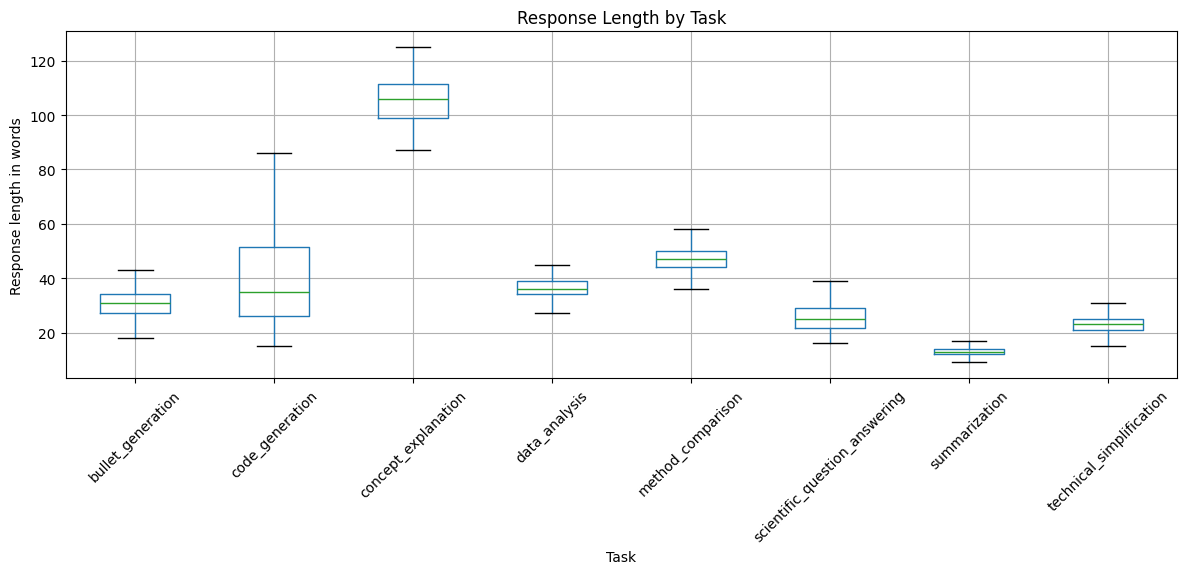

In [86]:
df.boxplot(
    column="response_words",
    by="task",
    figsize=(12, 6),
    rot=45,
    showfliers=False,
)

plt.xlabel("Task")
plt.ylabel("Response length in words")
plt.title("Response Length by Task")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 9. Create Train, Validation, and Test Splits

Create reproducible 80/10/10 splits while approximately preserving the task distribution. Identical normalized prompts are grouped together to prevent prompt leakage between training and evaluation.

In [90]:
from sklearn.model_selection import StratifiedGroupKFold

In [91]:
df["prompt_group"] = (
    df["normalized_system"]
    + "\n"
    + df["normalized_instruction"]
)

In [92]:
print("Total examples:", len(df))
print("Unique prompt groups:", df["prompt_group"].nunique())
print(
    "Examples belonging to repeated prompts:",
    df["prompt_group"].duplicated(keep=False).sum(),
)

Total examples: 1576
Unique prompt groups: 1576
Examples belonging to repeated prompts: 0


In [93]:
N_SPLITS = 10

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

df["fold"] = -1

for fold_number, (_, held_out_indices) in enumerate(
    splitter.split(
        X=df,
        y=df["task"],
        groups=df["prompt_group"],
    )
):
    df.loc[held_out_indices, "fold"] = fold_number

In [94]:
df["fold"].value_counts().sort_index()

fold
0    158
1    158
2    158
3    157
4    158
5    157
6    157
7    158
8    158
9    157
Name: count, dtype: int64

In [95]:
if (df["fold"] == -1).any():
    raise RuntimeError(
        "Some examples were not assigned to a fold."
    )

print("All examples were assigned to a fold.")

All examples were assigned to a fold.


In [96]:
df["split"] = "train"

df.loc[df["fold"] == 0, "split"] = "test"
df.loc[df["fold"] == 1, "split"] = "validation"

In [97]:
split_summary = (
    df["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .to_frame("count")
)

split_summary["percentage"] = (
    split_summary["count"] / len(df) * 100
).round(2)

split_summary

,count,percentage
split,,
train,1260,79.95
validation,158,10.03
test,158,10.03


In [98]:
task_counts_by_split = pd.crosstab(
    df["task"],
    df["split"],
)

task_counts_by_split

split,test,train,validation
task,,,
bullet_generation,19,161,20
code_generation,10,79,11
concept_explanation,20,160,20
data_analysis,20,160,20
method_comparison,20,161,19
scientific_question_answering,27,202,27
summarization,21,178,21
technical_simplification,21,159,20


In [99]:
task_percentage_by_split = pd.crosstab(
    df["task"],
    df["split"],
    normalize="columns",
).mul(100).round(2)

task_percentage_by_split

split,test,train,validation
task,,,
bullet_generation,12.03,12.78,12.66
code_generation,6.33,6.27,6.96
concept_explanation,12.66,12.70,12.66
data_analysis,12.66,12.70,12.66
method_comparison,12.66,12.78,12.03
scientific_question_answering,17.09,16.03,17.09
summarization,13.29,14.13,13.29
technical_simplification,13.29,12.62,12.66


In [100]:
missing_tasks_by_split = (
    task_counts_by_split == 0
).sum()

missing_tasks_by_split

split
test          0
train         0
validation    0
dtype: int64

In [101]:
if missing_tasks_by_split.sum() > 0:
    print(
        "Warning: Some tasks are missing from one or more splits:"
    )
    print(missing_tasks_by_split[missing_tasks_by_split > 0])
else:
    print("Every task is represented in every split.")

Every task is represented in every split.


In [102]:
train_prompts = set(
    df.loc[df["split"] == "train", "prompt_group"]
)

validation_prompts = set(
    df.loc[df["split"] == "validation", "prompt_group"]
)

test_prompts = set(
    df.loc[df["split"] == "test", "prompt_group"]
)

In [103]:
print(
    "Train-validation overlap:",
    len(train_prompts & validation_prompts),
)

print(
    "Train-test overlap:",
    len(train_prompts & test_prompts),
)

print(
    "Validation-test overlap:",
    len(validation_prompts & test_prompts),
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [104]:
assert train_prompts.isdisjoint(validation_prompts)
assert train_prompts.isdisjoint(test_prompts)
assert validation_prompts.isdisjoint(test_prompts)

print("No identical prompts appear across dataset splits.")

No identical prompts appear across dataset splits.


In [105]:
df[
    [
        "id",
        "task",
        "difficulty",
        "fold",
        "split",
        "instruction",
    ]
].sample(
    n=10,
    random_state=SEED,
)

,id,task,difficulty,fold,split,instruction
1246,researchgpt-01247,bullet_generation,intermediate,4,train,List four characteristics of spatial autocorre...
813,researchgpt-00814,method_comparison,intermediate,0,test,Compare Deep Learning and traditional machine ...
1173,researchgpt-01174,bullet_generation,intermediate,1,validation,List four ways traffic policies can reduce air...
534,researchgpt-00535,summarization,intermediate,6,train,Summarize the following faithfully paraphrased...
514,researchgpt-00515,summarization,intermediate,3,train,Summarize the following faithfully paraphrased...
1524,researchgpt-01525,code_generation,intermediate,8,train,Write Python code to calculate intersection ov...
522,researchgpt-00523,summarization,intermediate,9,train,Summarize the following faithfully paraphrased...
274,researchgpt-00275,concept_explanation,beginner,7,train,Explain buffer analysis.
494,researchgpt-00495,summarization,intermediate,8,train,Summarize the following faithfully paraphrased...
65,researchgpt-00066,scientific_question_answering,intermediate,4,train,What is land-use regression?


## 10. Create the Hugging Face Dataset

Convert the pandas train, validation, and test splits into a Hugging Face `DatasetDict` for tokenizer analysis and model training.

In [106]:
MODEL_COLUMNS = [
    "id",
    "category",
    "task",
    "difficulty",
    "messages",
]

In [107]:
train_df = (
    df.loc[df["split"] == "train", MODEL_COLUMNS]
    .reset_index(drop=True)
)

validation_df = (
    df.loc[df["split"] == "validation", MODEL_COLUMNS]
    .reset_index(drop=True)
)

test_df = (
    df.loc[df["split"] == "test", MODEL_COLUMNS]
    .reset_index(drop=True)
)

In [108]:
print("Training examples:", len(train_df))
print("Validation examples:", len(validation_df))
print("Test examples:", len(test_df))

Training examples: 1260
Validation examples: 158
Test examples: 158


In [109]:
from datasets import Dataset, DatasetDict


dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(
            train_df,
            preserve_index=False,
        ),
        "validation": Dataset.from_pandas(
            validation_df,
            preserve_index=False,
        ),
        "test": Dataset.from_pandas(
            test_df,
            preserve_index=False,
        ),
    }
)

In [110]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
    test: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
})

In [111]:
dataset["train"].features

{'id': Value(dtype='string', id=None),
 'category': Value(dtype='string', id=None),
 'task': Value(dtype='string', id=None),
 'difficulty': Value(dtype='string', id=None),
 'messages': [{'role': Value(dtype='string', id=None),
   'content': Value(dtype='string', id=None)}]}

In [112]:
dataset["train"][0]

{'id': 'researchgpt-00001',
 'category': 'Air Pollution',
 'task': 'scientific_question_answering',
 'difficulty': 'intermediate',
 'messages': [{'role': 'system',
   'content': 'You are ResearchGPT, a scientific research assistant.'},
  {'role': 'user',
   'content': 'Why must spatial autocorrelation be considered in air pollution studies?'},
  {'role': 'assistant',
   'content': 'Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.'}]}

In [113]:
sample = dataset["train"][0]

print("ID:", sample["id"])
print("Category:", sample["category"])
print("Task:", sample["task"])
print("Difficulty:", sample["difficulty"])

print("\nMessages:")

for message in sample["messages"]:
    print(f"\n{message['role'].upper()}:")
    print(message["content"])

ID: researchgpt-00001
Category: Air Pollution
Task: scientific_question_answering
Difficulty: intermediate

Messages:

SYSTEM:
You are ResearchGPT, a scientific research assistant.

USER:
Why must spatial autocorrelation be considered in air pollution studies?

ASSISTANT:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.


In [114]:
assert len(dataset["train"]) == len(train_df)
assert len(dataset["validation"]) == len(validation_df)
assert len(dataset["test"]) == len(test_df)

assert dataset["train"].column_names == MODEL_COLUMNS
assert dataset["validation"].column_names == MODEL_COLUMNS
assert dataset["test"].column_names == MODEL_COLUMNS

print("DatasetDict created successfully.")

DatasetDict created successfully.


## 11. Save the Processed Dataset

Save the Hugging Face `DatasetDict`, separate JSONL split files, and a complete audit file containing provenance and split information.

In [116]:
HF_DATASET_DIR = OUTPUT_DIR / "scientific_llm_dataset"

dataset.save_to_disk(str(HF_DATASET_DIR))

print("Saved Hugging Face dataset to:")
print(HF_DATASET_DIR.resolve())

Saving the dataset (0/1 shards):   0%|          | 0/1260 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/158 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/158 [00:00<?, ? examples/s]

Saved Hugging Face dataset to:
/Users/miladsaeedi/Desktop/Daily_Work_load/LLM_Hug_face/LLM_Course_projects/Project2/data/processed/scientific_llm_dataset


In [117]:
for split_name in ["train", "validation", "test"]:
    output_path = OUTPUT_DIR / f"{split_name}.jsonl"

    split_df = df.loc[
        df["split"] == split_name,
        MODEL_COLUMNS,
    ]

    split_df.to_json(
        output_path,
        orient="records",
        lines=True,
        force_ascii=False,
    )

    print(
        f"Saved {split_name}: "
        f"{len(split_df)} examples → {output_path}"
    )

Saved train: 1260 examples → ../data/processed/train.jsonl
Saved validation: 158 examples → ../data/processed/validation.jsonl
Saved test: 158 examples → ../data/processed/test.jsonl


In [118]:
AUDIT_PATH = OUTPUT_DIR / "dataset_audit.jsonl"

df.to_json(
    AUDIT_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Saved audit file to:")
print(AUDIT_PATH.resolve())

Saved audit file to:
/Users/miladsaeedi/Desktop/Daily_Work_load/LLM_Hug_face/LLM_Course_projects/Project2/data/processed/dataset_audit.jsonl


In [119]:
manifest = {
    "dataset_name": "scientific-llm-finetuning",
    "seed": SEED,
    "source_files": SOURCE_FILES,
    "total_source_examples": int(rows_before),
    "duplicates_removed": int(rows_removed),
    "final_examples": int(len(df)),
    "split_sizes": {
        split_name: int(
            (df["split"] == split_name).sum()
        )
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    },
    "task_distribution": {
        str(task): int(count)
        for task, count in df["task"].value_counts().items()
    },
    "difficulty_distribution": {
        str(difficulty): int(count)
        for difficulty, count
        in df["difficulty"].value_counts().items()
    },
}

In [120]:
MANIFEST_PATH = OUTPUT_DIR / "dataset_manifest.json"

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Saved dataset manifest to:")
print(MANIFEST_PATH.resolve())

Saved dataset manifest to:
/Users/miladsaeedi/Desktop/Daily_Work_load/LLM_Hug_face/LLM_Course_projects/Project2/data/processed/dataset_manifest.json


In [121]:
manifest

{'dataset_name': 'scientific-llm-finetuning',
 'seed': 42,
 'source_files': ['Answered_questions.json',
  'Concept_Explanation_examples_200.json',
  'Abstract_summaries_200.json',
  'Method_comparisons_200.json',
  'Technical_simplifications_200.json',
  'Bullet_generation_200.json',
  'Data_analysis_200.json',
  'Code_generation_100.json'],
 'total_source_examples': 1576,
 'duplicates_removed': 0,
 'final_examples': 1576,
 'split_sizes': {'train': 1260, 'validation': 158, 'test': 158},
 'task_distribution': {'scientific_question_answering': 256,
  'summarization': 220,
  'concept_explanation': 200,
  'method_comparison': 200,
  'technical_simplification': 200,
  'bullet_generation': 200,
  'data_analysis': 200,
  'code_generation': 100},
 'difficulty_distribution': {'intermediate': 1184,
  'easy': 201,
  'advanced': 128,
  'beginner': 63}}

In [122]:
from datasets import load_from_disk


reloaded_dataset = load_from_disk(
    str(HF_DATASET_DIR)
)

reloaded_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
    test: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
})

In [123]:
for split_name in [
    "train",
    "validation",
    "test",
]:
    original_size = len(dataset[split_name])
    reloaded_size = len(reloaded_dataset[split_name])

    print(
        f"{split_name}: "
        f"original={original_size}, "
        f"reloaded={reloaded_size}"
    )

    assert original_size == reloaded_size

print("Saved dataset was reloaded successfully.")

train: original=1260, reloaded=1260
validation: original=158, reloaded=158
test: original=158, reloaded=158
Saved dataset was reloaded successfully.


## 12. Final Dataset Verification

Run final integrity checks to confirm that the processed dataset is complete, reproducible, duplicate-free, and ready for tokenizer analysis and fine-tuning.

In [124]:
assert df["id"].is_unique

print("All final IDs are unique.")

All final IDs are unique.


In [125]:
FINAL_REQUIRED_COLUMNS = [
    "id",
    "category",
    "task",
    "difficulty",
    "messages",
    "split",
]

missing_final_values = df[FINAL_REQUIRED_COLUMNS].isna().sum()

print(missing_final_values)

assert missing_final_values.sum() == 0

print("No missing values found in final required columns.")

id            0
category      0
task          0
difficulty    0
messages      0
split         0
dtype: int64
No missing values found in final required columns.


In [126]:
remaining_full_duplicates = df.duplicated(
    subset=[
        "normalized_system",
        "normalized_instruction",
        "normalized_response",
    ]
).sum()

print(
    "Remaining full duplicate conversations:",
    remaining_full_duplicates,
)

assert remaining_full_duplicates == 0

Remaining full duplicate conversations: 0


In [127]:
remaining_full_duplicates = df.duplicated(
    subset=[
        "normalized_system",
        "normalized_instruction",
        "normalized_response",
    ]
).sum()

print(
    "Remaining full duplicate conversations:",
    remaining_full_duplicates,
)

assert remaining_full_duplicates == 0

Remaining full duplicate conversations: 0


In [128]:
prompt_split_counts = (
    df.groupby("prompt_group")["split"]
    .nunique()
)

leaking_prompt_groups = prompt_split_counts[
    prompt_split_counts > 1
]

print(
    "Prompt groups appearing in multiple splits:",
    len(leaking_prompt_groups),
)

assert len(leaking_prompt_groups) == 0

print("No identical prompt leakage detected.")

Prompt groups appearing in multiple splits: 0
No identical prompt leakage detected.


In [129]:
split_total = sum(
    len(dataset[split_name])
    for split_name in [
        "train",
        "validation",
        "test",
    ]
)

print("Rows in pandas DataFrame:", len(df))
print("Rows in DatasetDict:", split_total)

assert split_total == len(df)

Rows in pandas DataFrame: 1576
Rows in DatasetDict: 1576


In [130]:
tasks_in_dataset = set(df["task"].unique())

for split_name in [
    "train",
    "validation",
    "test",
]:
    tasks_in_split = set(
        df.loc[
            df["split"] == split_name,
            "task",
        ].unique()
    )

    missing_tasks = tasks_in_dataset - tasks_in_split

    print(
        f"{split_name}: "
        f"{len(tasks_in_split)} tasks, "
        f"missing={sorted(missing_tasks)}"
    )

train: 8 tasks, missing=[]
validation: 8 tasks, missing=[]
test: 8 tasks, missing=[]


In [131]:
final_summary = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test",
            "total",
        ],
        "examples": [
            len(dataset["train"]),
            len(dataset["validation"]),
            len(dataset["test"]),
            len(df),
        ],
    }
)

final_summary["percentage"] = (
    final_summary["examples"] / len(df) * 100
).round(2)

final_summary.loc[
    final_summary["split"] == "total",
    "percentage",
] = 100.0

final_summary

,split,examples,percentage
0,train,1260,79.95
1,validation,158,10.03
2,test,158,10.03
3,total,1576,100.00


In [132]:
print("=" * 60)
print("DATASET CREATION COMPLETED")
print("=" * 60)

print(f"Source examples:       {rows_before:,}")
print(f"Duplicates removed:    {rows_removed:,}")
print(f"Final examples:        {len(df):,}")

print("\nSplit sizes:")
for split_name in [
    "train",
    "validation",
    "test",
]:
    print(
        f"  {split_name:<10} "
        f"{len(dataset[split_name]):>5}"
    )

print("\nQuality checks:")
print("  ✓ Valid chat structure")
print("  ✓ Unique final IDs")
print("  ✓ No full duplicates")
print("  ✓ No identical prompt leakage")
print("  ✓ Dataset saved successfully")

print("\nNext notebook: 02_tokenizer_analysis.ipynb")

DATASET CREATION COMPLETED
Source examples:       1,576
Duplicates removed:    0
Final examples:        1,576

Split sizes:
  train       1260
  validation   158
  test         158

Quality checks:
  ✓ Valid chat structure
  ✓ Unique final IDs
  ✓ No full duplicates
  ✓ No identical prompt leakage
  ✓ Dataset saved successfully

Next notebook: 02_tokenizer_analysis.ipynb
